# IF3270 Machine Learning
# CNN Forward Propagation From Scratch
## Inference and Evaluation Pipeline

This notebook focuses on:
- loading trained Keras weights
- converting the shared architecture into the scratch implementation
- running forward propagation from scratch on the test split
- comparing shared and non-shared parameter variants
- demonstrating batch inference

Group Number: 69

Group Members:
- Mochammad Fariz Rifqi Rizqulloh (13523069)
- Muhammad Jibril Ibrahim (13523085)
- Nayaka Ghana Subrata (13523090)

## 0. Runtime Notes

This notebook assumes the training artifacts from `cnn-train.ipynb` already exist.
If the training artifacts are missing, run the training notebook first.

## 1. Import Libraries

### 1.1 Environment Setup

This section resolves the repository root and adds the source directory to `sys.path` before project imports are loaded.

In [1]:
from pathlib import Path
import sys

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "src").exists():
    REPO_ROOT = REPO_ROOT.parent

SRC_ROOT = REPO_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

### 1.2 Import Libraries

All imports are grouped in this cell after the project path has been prepared.

In [2]:
import json
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import tensorflow as tf
try:
    tf.config.set_visible_devices([], "GPU")
except Exception:
    pass

from cnn import (
    compare_keras_and_scratch,
    compare_shared_and_non_shared,
    extract_feature_maps,
    get_last_feature_layer,
    keras_to_scratch,
    list_feature_layers,
    load_image_classification_dataset,
    load_image,
    load_image_batch,
    load_saved_classifier,
    make_gradcam_heatmap,
    overlay_heatmap,
    plot_feature_maps,
    plot_gradcam,
    predict_scratch_split,
    resolve_dataset_root,
    save_figure,
    set_random_seed,
)

I0000 00:00:1778769486.671122    1071 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


E0000 00:00:1778769570.779986    1071 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


## 2. Evaluation Configuration

In [3]:
SEED = 42
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 4

DATASET_ROOT = resolve_dataset_root()
ARTIFACTS_DIR = REPO_ROOT / "artifacts" / "cnn"
SHARED_OUTPUT_DIR = ARTIFACTS_DIR / "shared"
NON_SHARED_OUTPUT_DIR = ARTIFACTS_DIR / "non_shared"
REPORTS_DIR = ARTIFACTS_DIR / "reports"

In [4]:
set_random_seed(SEED)
tf.keras.utils.set_random_seed(SEED)
tf.config.optimizer.set_jit(False)

print("TensorFlow:", tf.__version__)
print("Available GPUs:", tf.config.list_physical_devices("GPU"))
print("The forward notebook runs on CPU by default for stable model loading in WSL.")

TensorFlow: 2.21.0
Available GPUs: []
The forward notebook runs on CPU by default for stable model loading in WSL.


## 3. Load Dataset and Training Artifacts

In [5]:
dataset = load_image_classification_dataset(
    dataset_root=DATASET_ROOT,
    validation_split=0.2,
    random_state=SEED,
)

shared_results_path = REPORTS_DIR / "shared_results.csv"
non_shared_results_path = REPORTS_DIR / "non_shared_results.csv"

if not shared_results_path.exists():
    raise FileNotFoundError(
        f"Shared results not found: {shared_results_path}. Run cnn-train.ipynb first."
    )

shared_results = pd.read_csv(shared_results_path).sort_values("val_macro_f1", ascending=False)
shared_results.head()

,name,layers,filters,kernels,pooling,local_connectivity,val_loss,val_accuracy,val_macro_f1,params,best_epoch
0,cnn_l3_f24-24-24_k3x3-3x3-3x3_avg,3,"(24, 24, 24)","((3, 3), (3, 3), (3, 3))",avg,False,0.659108,0.775561,0.776496,1215766,3
1,cnn_l3_f24-24-24_k3x3-3x3-3x3_max,3,"(24, 24, 24)","((3, 3), (3, 3), (3, 3))",max,False,0.835253,0.766655,0.767425,1215766,4
2,cnn_l3_f16-16-16_k3x3-3x3-3x3_avg,3,"(16, 16, 16)","((3, 3), (3, 3), (3, 3))",avg,False,0.776668,0.762024,0.764288,808358,4
3,cnn_l3_f16-16-16_k3x3-3x3-3x3_max,3,"(16, 16, 16)","((3, 3), (3, 3), (3, 3))",max,False,1.061295,0.752761,0.753414,808358,5
4,cnn_l3_f24-24-24_k5x5-5x5-5x5_max,3,"(24, 24, 24)","((5, 5), (5, 5), (5, 5))",max,False,0.775718,0.747417,0.748608,1235350,3


In [6]:
best_shared_name = shared_results.iloc[0]["name"]
best_shared_history_path = SHARED_OUTPUT_DIR / f"{best_shared_name}_history.json"
best_shared_summary_path = SHARED_OUTPUT_DIR / f"{best_shared_name}_summary.json"

best_shared_summary = json.loads(best_shared_summary_path.read_text(encoding="utf-8"))
IMAGE_SIZE = tuple(best_shared_summary["config"]["input_shape"][:2])

non_shared_name = f"{best_shared_name}_local"
non_shared_history_path = NON_SHARED_OUTPUT_DIR / f"{non_shared_name}_history.json"

print("Best shared model:", best_shared_name)
print("Model image size:", IMAGE_SIZE)
print("Shared artifact directory:", SHARED_OUTPUT_DIR)
print("Non-shared artifact directory:", NON_SHARED_OUTPUT_DIR)

Best shared model: cnn_l3_f24-24-24_k3x3-3x3-3x3_avg
Model image size: (224, 224)
Shared artifact directory: /mnt/c/Users/Ghana/Documents/tubes2-ml/Tubes2-ML/artifacts/cnn/shared
Non-shared artifact directory: /mnt/c/Users/Ghana/Documents/tubes2-ml/Tubes2-ML/artifacts/cnn/non_shared


## 4. Load Keras Weights and Convert to Scratch

The scratch forward pass reads the trained Keras weights and rebuilds an equivalent NumPy-based architecture.

In [7]:
shared_model = load_saved_classifier(SHARED_OUTPUT_DIR, best_shared_name, compile=False)
scratch_model = keras_to_scratch(shared_model)

print("Keras model:", shared_model.name)
print("Scratch model:", scratch_model.name)
print("Parameter count:", shared_model.count_params())

Keras model: cnn_l3_f24-24-24_k3x3-3x3-3x3_avg
Scratch model: cnn_l3_f24-24-24_k3x3-3x3-3x3_avg
Parameter count: 1215766


In [8]:
sample_predictions = predict_scratch_split(
    scratch_model,
    dataset.test,
    target_size=IMAGE_SIZE,
    batch_size=8,
)
print("Scratch prediction tensor shape:", sample_predictions.shape)
print("First 5 predicted labels:", np.argmax(sample_predictions[:5], axis=-1))

Scratch prediction tensor shape: (3000, 6)
First 5 predicted labels: [0 5 0 0 0]


## 5. Keras vs Scratch on the Test Split

This comparison is performed on the best shared architecture selected from the training pipeline.

In [9]:
scratch_comparison = compare_keras_and_scratch(
    shared_model,
    dataset.test,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    normalize=True,
)
scratch_comparison

{'keras_macro_f1': 0.7701675885565608,
 'scratch_macro_f1': 0.770236174720314,
 'max_probability_gap': 0.23160585761070251,
 'mean_probability_gap': 0.004551958758383989}

## 6. Test Inference Gallery

This gallery shows a small sample from the test split together with the ground-truth label, the Keras prediction, and the scratch prediction.

In [10]:
def plot_test_inference_gallery(split, keras_model, scratch_model, class_names, target_size, sample_count=6):
    sample_paths = split.image_paths[:sample_count]
    sample_labels = split.labels[:sample_count]
    sample_batch = load_image_batch(sample_paths, target_size=target_size)

    keras_predictions = keras_model.predict(sample_batch, verbose=0)
    scratch_predictions = scratch_model.predict(sample_batch, batch_size=sample_count)

    keras_labels = np.argmax(keras_predictions, axis=-1)
    scratch_labels = np.argmax(scratch_predictions, axis=-1)

    fig, axes = plt.subplots(2, 3, figsize=(14, 9))
    axes = axes.flat

    for axis, image_path, true_label, keras_label, scratch_label in zip(
        axes,
        sample_paths,
        sample_labels,
        keras_labels,
        scratch_labels,
    ):
        image = load_image(image_path, target_size=target_size)
        axis.imshow(image)
        axis.set_title(
            "\n".join(
                [
                    Path(image_path).name,
                    f"GT: {class_names[int(true_label)]}",
                    f"Keras: {class_names[int(keras_label)]}",
                    f"Scratch: {class_names[int(scratch_label)]}",
                ]
            ),
            fontsize=9,
        )
        axis.axis("off")

    for axis in axes[len(sample_paths):]:
        axis.axis("off")

    plt.tight_layout()
    plt.show()

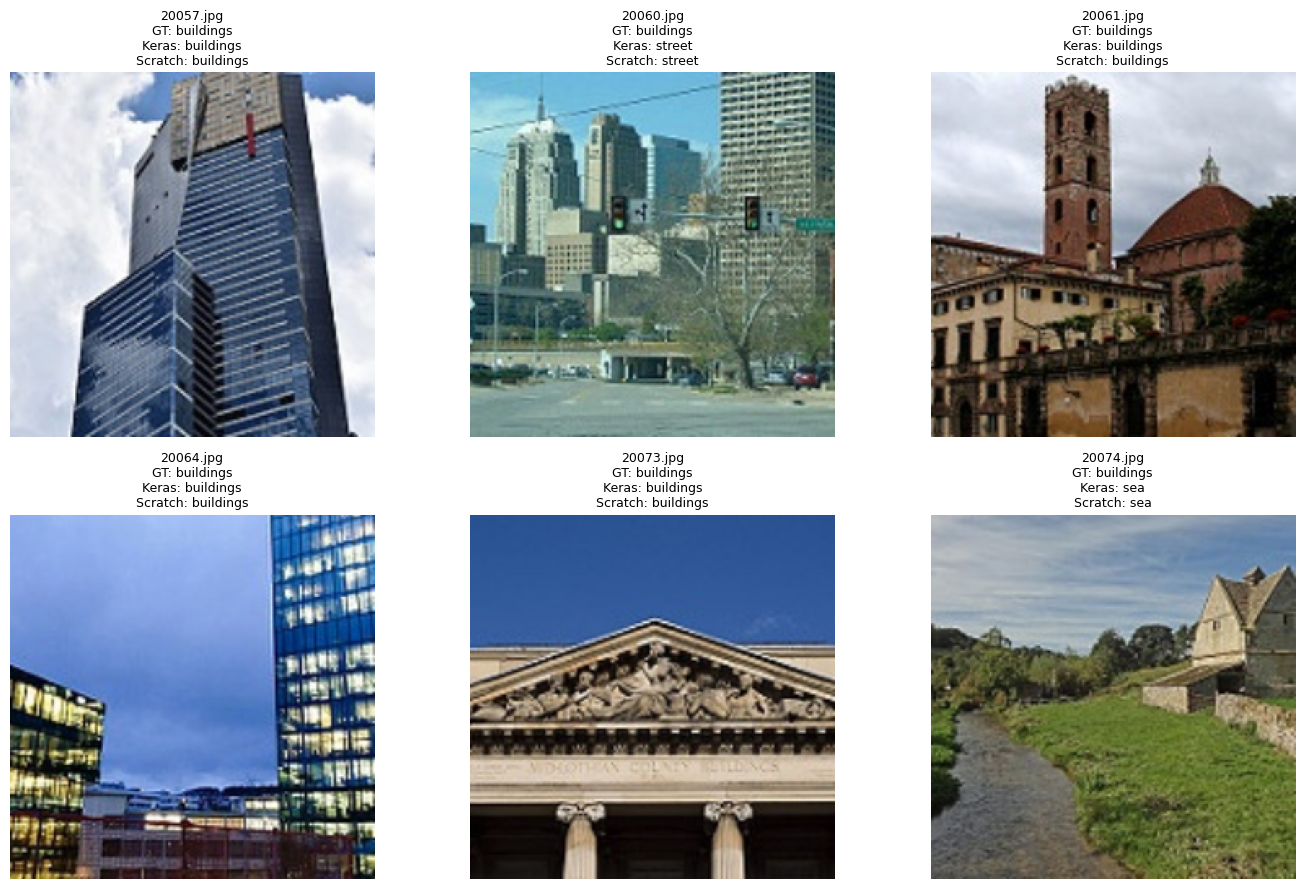

In [11]:
plot_test_inference_gallery(
    dataset.test,
    shared_model,
    scratch_model,
    dataset.class_names,
    IMAGE_SIZE,
    sample_count=6,
)

## 7. Shared vs Non-Shared

The non-shared architecture replaces all convolution blocks with `LocallyConnected2D` and is evaluated on the same test split.

In [12]:
non_shared_summary_path = NON_SHARED_OUTPUT_DIR / f"{non_shared_name}_summary.json"
if not non_shared_summary_path.exists():
    raise FileNotFoundError(
        f"Non-shared summary not found: {non_shared_summary_path}. "
        "Run scripts/run_cnn_pipeline.py or train the non-shared variant first."
    )

non_shared_model = load_saved_classifier(NON_SHARED_OUTPUT_DIR, non_shared_name, compile=False)
shared_vs_non_shared = compare_shared_and_non_shared(
    shared_model,
    non_shared_model,
    dataset.test,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
)
shared_vs_non_shared

{'shared_macro_f1': 0.7701675885565608,
 'non_shared_macro_f1': 0.049645390070879696,
 'shared_params': 1215766,
 'non_shared_params': 116584390}

In [13]:
def load_history(history_path):
    with open(history_path, "r", encoding="utf-8") as file:
        return json.load(file)

def plot_history_pair(shared_history_path, non_shared_history_path):
    shared_history = load_history(shared_history_path)
    non_shared_history = load_history(non_shared_history_path)
    epochs_shared = range(1, len(shared_history["loss"]) + 1)
    epochs_local = range(1, len(non_shared_history["loss"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs_shared, shared_history["val_loss"], label="shared", marker="o")
    axes[0].plot(epochs_local, non_shared_history["val_loss"], label="non-shared", marker="o")
    axes[0].set_title("Validation Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(epochs_shared, shared_history["val_macro_f1"], label="shared", marker="o")
    axes[1].plot(epochs_local, non_shared_history["val_macro_f1"], label="non-shared", marker="o")
    axes[1].set_title("Validation Macro F1")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

    fig.suptitle(
        f"Shared epochs: {len(shared_history['loss'])} | "
        f"Non-shared epochs: {len(non_shared_history['loss'])}",
        fontsize=11,
    )
    plt.tight_layout()
    plt.show()

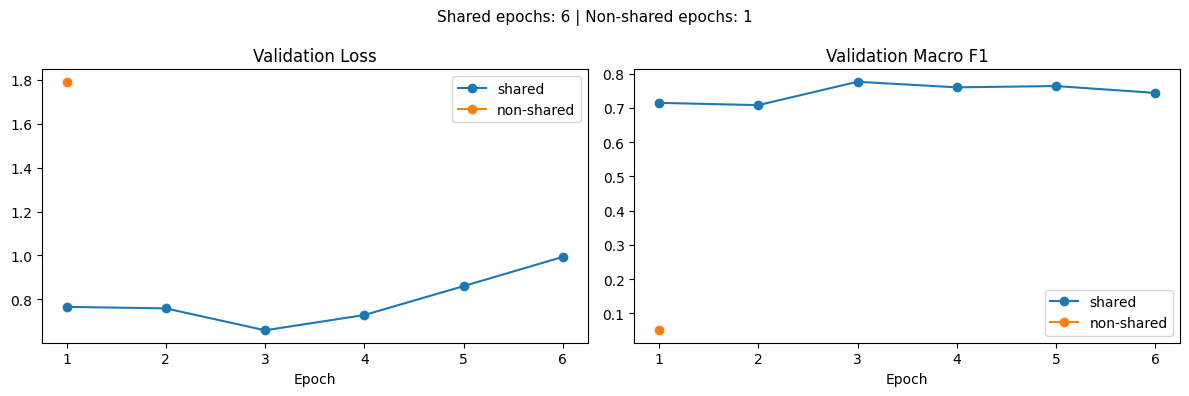

In [14]:
if non_shared_history_path.exists():
    plot_history_pair(best_shared_history_path, non_shared_history_path)

## 8. Feature Visualization

This bonus section visualizes:
- intermediate feature maps from convolutional layers
- Grad-CAM to highlight the image regions that most influence the prediction

In [15]:
feature_layer_names = list_feature_layers(shared_model)
feature_layer_names

['block1_conv', 'block2_conv', 'block3_conv']

In [16]:
sample_path = dataset.test.image_paths[0]
sample_image = load_image(sample_path, target_size=IMAGE_SIZE)
sample_image.shape

(224, 224, 3)

In [17]:
feature_maps = extract_feature_maps(
    shared_model,
    sample_image,
    layer_names=feature_layer_names[:2],
)
feature_maps.keys()

/mnt/c/Users/Ghana/Documents/tubes2-ml/Tubes2-ML/.venv/lib/python3.10/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


dict_keys(['block1_conv', 'block2_conv'])

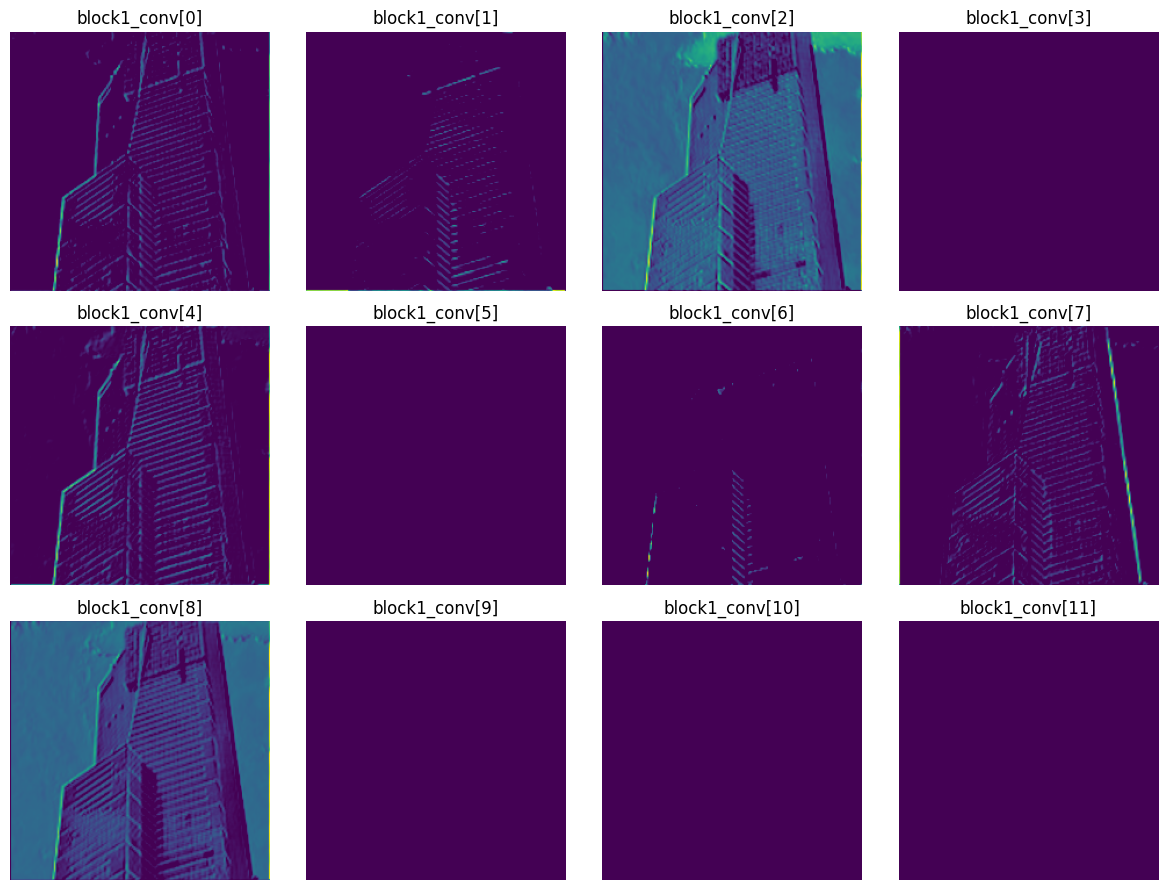

In [18]:
first_feature_layer = feature_layer_names[0]
feature_maps_fig = plot_feature_maps(
    feature_maps,
    layer_name=first_feature_layer,
    image_index=0,
    max_maps=12,
    cols=4,
)
plt.show()

In [19]:
gradcam_heatmap, gradcam_class_index, gradcam_layer_name = make_gradcam_heatmap(
    shared_model,
    sample_image,
    layer_name=get_last_feature_layer(shared_model),
)
gradcam_heatmap.shape, gradcam_class_index, gradcam_layer_name

((56, 56), 0, 'block3_conv')

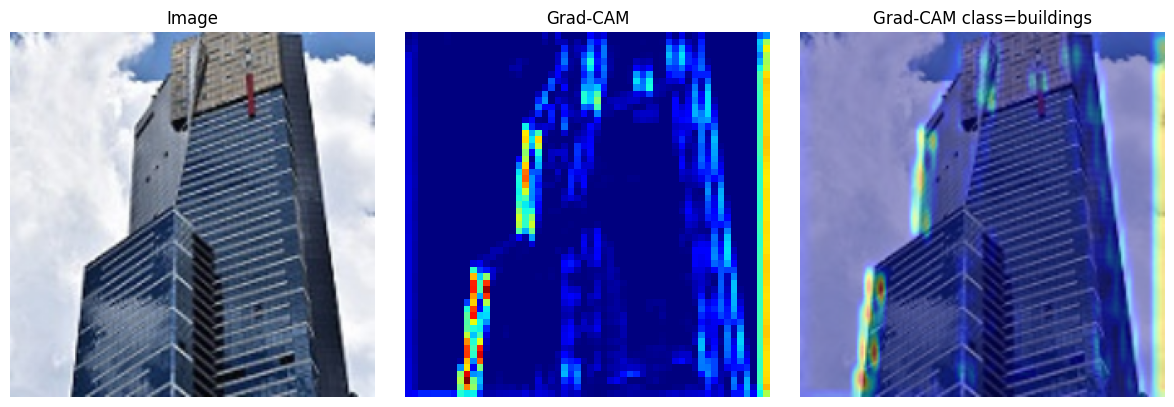

In [20]:
gradcam_fig = plot_gradcam(
    sample_image,
    gradcam_heatmap,
    alpha=0.4,
    title=f"Grad-CAM class={dataset.class_names[gradcam_class_index]}",
)
plt.show()

### 8.1 Grad-CAM Gallery by Class

The gallery below shows one test example per class with its Grad-CAM overlay.

In [21]:
def select_one_example_per_class(split, class_names):
    selected = []
    seen = set()
    for image_path, label in zip(split.image_paths, split.labels):
        label = int(label)
        if label in seen:
            continue
        selected.append((image_path, label))
        seen.add(label)
        if len(seen) == len(class_names):
            break
    return selected

def plot_gradcam_class_gallery(model, split, class_names, target_size, layer_name=None, alpha=0.4):
    examples = select_one_example_per_class(split, class_names)
    rows, cols = 2, 3
    fig, axes = plt.subplots(rows, cols, figsize=(15, 9))
    axes = axes.flatten()

    for axis in axes:
        axis.axis("off")

    for axis, (image_path, true_label) in zip(axes, examples):
        image = load_image(image_path, target_size=target_size)
        heatmap, predicted_index, _ = make_gradcam_heatmap(
            model,
            image,
            layer_name=layer_name,
        )
        overlay = overlay_heatmap(image, heatmap, alpha=alpha)
        axis.imshow(overlay)
        axis.set_title(
            "\n".join(
                [
                    Path(image_path).name,
                    f"GT: {class_names[true_label]}",
                    f"Pred: {class_names[predicted_index]}",
                ]
            ),
            fontsize=9,
        )
        axis.axis("off")

    fig.suptitle("Grad-CAM Overlays by Class", fontsize=14)
    plt.tight_layout()
    plt.show()
    return fig

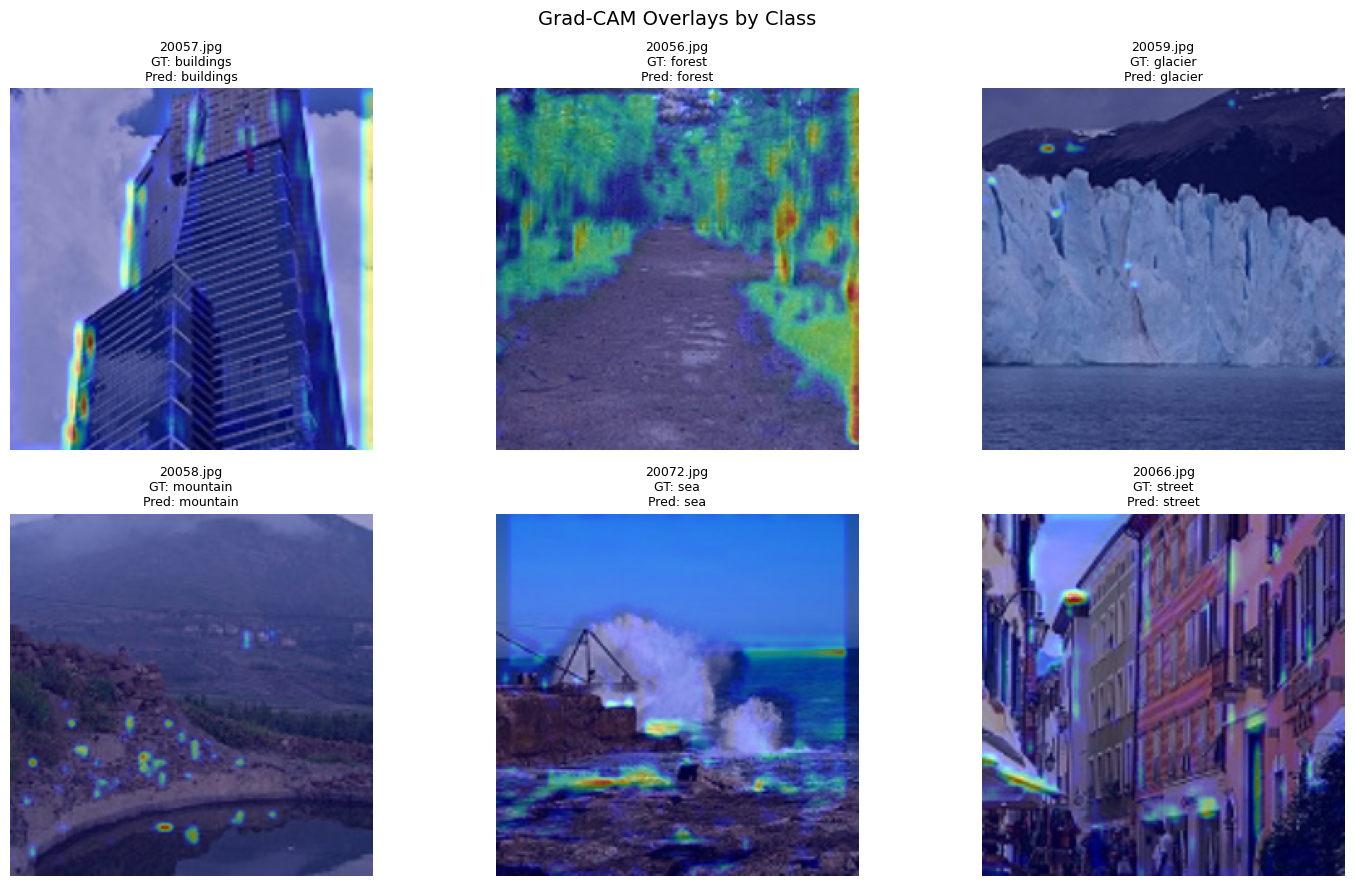

In [22]:
gradcam_gallery_fig = plot_gradcam_class_gallery(
    shared_model,
    dataset.test,
    dataset.class_names,
    IMAGE_SIZE,
    layer_name=get_last_feature_layer(shared_model),
    alpha=0.4,
)

In [23]:
VIS_DIR = REPORTS_DIR / "visualizations"
feature_map_path = save_figure(feature_maps_fig, VIS_DIR / "feature_maps.png")
gradcam_path = save_figure(gradcam_fig, VIS_DIR / "gradcam.png")
gradcam_gallery_path = save_figure(gradcam_gallery_fig, VIS_DIR / "gradcam_by_class.png")
print("Saved:", feature_map_path)
print("Saved:", gradcam_path)
print("Saved:", gradcam_gallery_path)

Saved: /mnt/c/Users/Ghana/Documents/tubes2-ml/Tubes2-ML/artifacts/cnn/reports/visualizations/feature_maps.png
Saved: /mnt/c/Users/Ghana/Documents/tubes2-ml/Tubes2-ML/artifacts/cnn/reports/visualizations/gradcam.png
Saved: /mnt/c/Users/Ghana/Documents/tubes2-ml/Tubes2-ML/artifacts/cnn/reports/visualizations/gradcam_by_class.png


## 9. Batch Inference

In [24]:
batch_predictions = predict_scratch_split(
    scratch_model,
    dataset.test,
    target_size=IMAGE_SIZE,
    batch_size=16,
)

single_batch_predictions = predict_scratch_split(
    scratch_model,
    dataset.test,
    target_size=IMAGE_SIZE,
    batch_size=1,
)

print("Batch prediction shape:", batch_predictions.shape)
print("Max abs diff vs batch_size=1:", float(np.max(np.abs(batch_predictions - single_batch_predictions))))

Batch prediction shape: (3000, 6)
Max abs diff vs batch_size=1: 3.069639205932617e-06


## 10. Optional Inference on `seg_pred`

The `seg_pred` directory usually contains unlabeled images intended for prediction demos.
This section runs scratch inference on a small sample from `seg_pred` and reports the predicted class names.

In [25]:
pred_root = DATASET_ROOT / "seg_pred"
pred_paths = sorted(pred_root.rglob("*.jpg"))[:16] if pred_root.exists() else []

if not pred_paths:
    print(f"No prediction images found under: {pred_root}")
else:
    pred_batch = predict_scratch_split(
        scratch_model,
        type("PredSplit", (), {"image_paths": pred_paths})(),
        target_size=IMAGE_SIZE,
        batch_size=8,
    )
    pred_labels = np.argmax(pred_batch, axis=-1)
    pred_table = pd.DataFrame(
        {
            "image_path": [str(path) for path in pred_paths],
            "predicted_class_index": pred_labels,
            "predicted_class_name": [dataset.class_names[index] for index in pred_labels],
        }
    )
    pred_table.head(10)

In [26]:
def plot_prediction_gallery(image_paths, predicted_names, target_size, cols=3):
    if not image_paths:
        print("No images available.")
        return

    rows = int(np.ceil(len(image_paths) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
    axes = np.atleast_1d(axes).reshape(rows, cols)

    for axis in axes.flat:
        axis.axis("off")

    for axis, image_path, predicted_name in zip(axes.flat, image_paths, predicted_names):
        image = load_image(image_path, target_size=target_size)
        axis.imshow(image)
        axis.set_title(f"{Path(image_path).name}\nPred: {predicted_name}", fontsize=9)
        axis.axis("off")

    plt.tight_layout()
    plt.show()

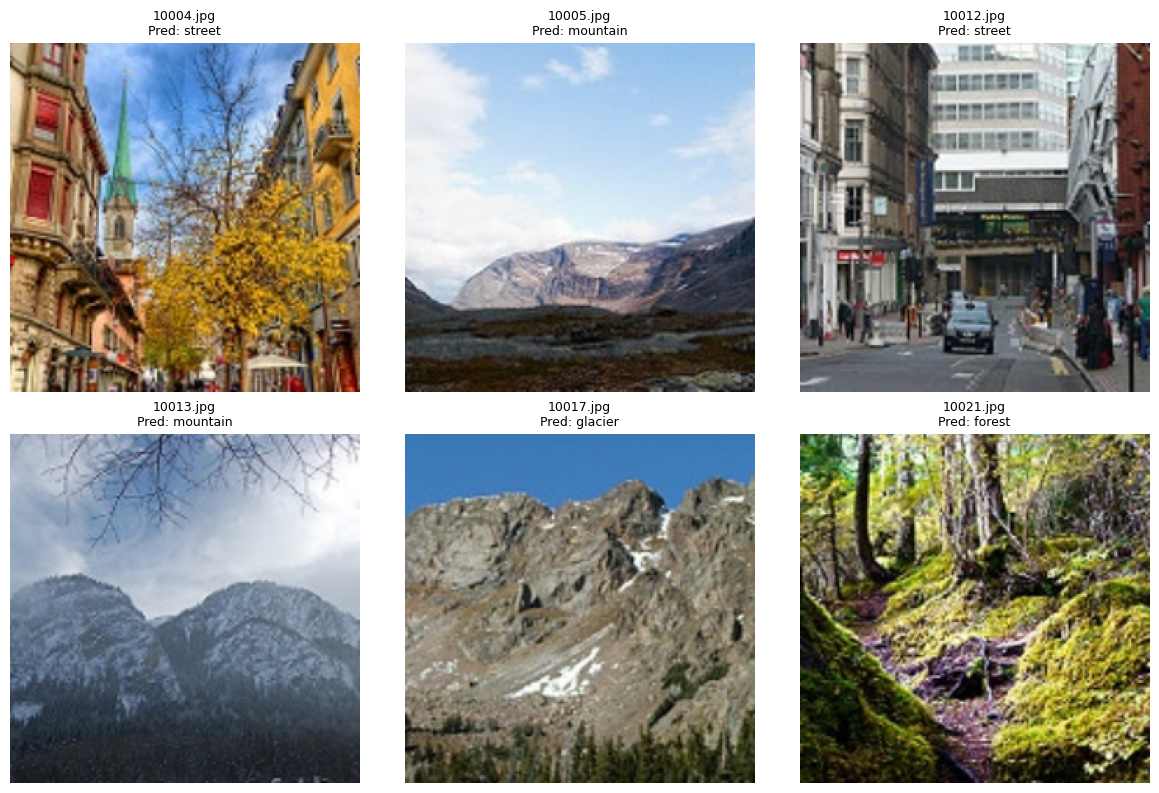

In [27]:
if pred_paths:
    plot_prediction_gallery(
        pred_paths[:6],
        pred_table["predicted_class_name"].tolist()[:6],
        IMAGE_SIZE,
        cols=3,
    )

## 11. Evaluation Artifact Summary

In [28]:
report_paths = [
    REPORTS_DIR / "shared_results.csv",
    REPORTS_DIR / "keras_vs_scratch_test.json",
    REPORTS_DIR / "shared_vs_non_shared_test.json",
    REPORTS_DIR / "visualizations" / "feature_maps.png",
    REPORTS_DIR / "visualizations" / "gradcam.png",
    REPORTS_DIR / "visualizations" / "gradcam_by_class.png",
]
pd.DataFrame({"report": [str(path) for path in report_paths], "exists": [path.exists() for path in report_paths]})

,report,exists
0,/mnt/c/Users/Ghana/Documents/tubes2-ml/Tubes2-...,True
1,/mnt/c/Users/Ghana/Documents/tubes2-ml/Tubes2-...,True
2,/mnt/c/Users/Ghana/Documents/tubes2-ml/Tubes2-...,True
3,/mnt/c/Users/Ghana/Documents/tubes2-ml/Tubes2-...,True
4,/mnt/c/Users/Ghana/Documents/tubes2-ml/Tubes2-...,True
5,/mnt/c/Users/Ghana/Documents/tubes2-ml/Tubes2-...,True
